# DSA210 Milestone 1: Data Collection, EDA, and Hypothesis Testing

## Project Topic
This project investigates the relationship between coffee consumption and lifestyle factors such as sleep quality, stress level, and daily habits.

## Goal
The goal of this notebook is to explore the dataset, assess its quality, visualize important patterns, and test hypotheses about the relationship between coffee consumption and sleep/lifestyle variables.

## 1) Load the Dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

df = pd.read_excel("DSA210 (Responses).xlsx")
df.head()

,Timestamp,Email Address,What is your age?,What is your gender?,How many cups of coffee do you drink per day?,What type of coffee do you usually drink?,How many hours do you sleep on average per night?,How would you rate your sleep quality?,How would you rate your stress level?,How many hours do you spend on screens before sleep?,Do you exercise regularly?
0,2026-04-06 16:17:08.864,ozgul@baygan.com,56,Female,1,Turkish coffee,9.0,4,2,2.0,No
1,2026-04-06 16:17:11.765,ahmet@baygan.com,66,Male,1,Turkish coffee,8.0,4,2,2.0,Yes
2,2026-04-06 16:22:33.923,busra.cecanpinar@gmail.com,52,Female,1,Americano,7.0,3,3,9.0,No
3,2026-04-06 16:23:04.059,lara.avci2@gmail.com,21,Female,3,Latte,6.0,3,4,1.5,No
4,2026-04-06 16:23:45.713,karya.ersoy@gmail.com,22,Female,0,Turkish coffee,7.0,4,4,2.0,No


## 2) Rename the Columns

In [29]:
df.columns = [
    "timestamp",
    "email",
    "age",
    "gender",
    "coffee",
    "coffee_type",
    "sleep_hours",
    "sleep_quality",
    "stress",
    "screen_time",
    "exercise"
]

# Drop columns that are not useful for analysis
# 'email' contains personal data (privacy concern) and 'timestamp' is not needed
df.drop(columns=["email", "timestamp"], inplace=True)

df.head()

,age,gender,coffee,coffee_type,sleep_hours,sleep_quality,stress,screen_time,exercise
0,56,Female,1,Turkish coffee,9.0,4,2,2.0,No
1,66,Male,1,Turkish coffee,8.0,4,2,2.0,Yes
2,52,Female,1,Americano,7.0,3,3,9.0,No
3,21,Female,3,Latte,6.0,3,4,1.5,No
4,22,Female,0,Turkish coffee,7.0,4,4,2.0,No


## 3) Data Overview

In [30]:
print("Shape:", df.shape)

Shape: (106, 9)


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            106 non-null    int64  
 1   gender         106 non-null    object 
 2   coffee         106 non-null    int64  
 3   coffee_type    106 non-null    object 
 4   sleep_hours    106 non-null    float64
 5   sleep_quality  106 non-null    int64  
 6   stress         106 non-null    int64  
 7   screen_time    106 non-null    float64
 8   exercise       106 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 7.6+ KB


In [32]:
df.describe()

,age,coffee,sleep_hours,sleep_quality,stress,screen_time
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,27.273585,1.688679,7.250000,3.245283,3.556604,2.183962
std,12.674333,1.221733,1.263499,0.881679,1.179832,2.670229
min,13.000000,0.000000,4.000000,1.000000,1.000000,0.000000
25%,21.000000,1.000000,6.250000,3.000000,3.000000,1.000000
50%,22.000000,1.000000,7.000000,3.000000,4.000000,1.500000
75%,23.000000,2.000000,8.000000,4.000000,5.000000,2.000000
max,66.000000,5.000000,10.000000,5.000000,5.000000,20.000000


Each row represents one participant response. Each column represents a variable collected from the survey. The dataset contains **106 participants** and **9 variables** (after removing email and timestamp).

## 4) Attribute Types

The variables in this dataset can be grouped as follows:

- **Categorical (Nominal)**: `gender`, `coffee_type`, `exercise`  
- **Ordinal**: `stress` (1–5 scale), `sleep_quality` (1–5 scale)  
- **Numerical (Discrete)**: `age`, `coffee` (cups per day)  
- **Numerical (Continuous)**: `sleep_hours`, `screen_time`

## 5) Data Quality Check

Before exploring the data, we check for missing values, duplicates, and potential outliers.

In [33]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
age              0
gender           0
coffee           0
coffee_type      0
sleep_hours      0
sleep_quality    0
stress           0
screen_time      0
exercise         0
dtype: int64

Duplicate rows: 0


In [34]:
# Check for potential outliers in screen_time
# max=20 in describe() is suspicious — let's inspect high values
print("screen_time > 8 hours (possible outliers):")
print(df[df["screen_time"] > 8][["age", "coffee", "screen_time", "stress"]])

screen_time > 8 hours (possible outliers):
    age  coffee  screen_time  stress
2    52       1          9.0       3
54   23       3         20.0       5
72   23       1         15.0       5


The `screen_time` variable has a maximum of 20 hours, which is an extreme value. These rows are kept in the analysis but noted as potential outliers. No missing values were found in the dataset.

## 6) Exploratory Data Analysis

### 6.1 Distribution of Numerical Variables

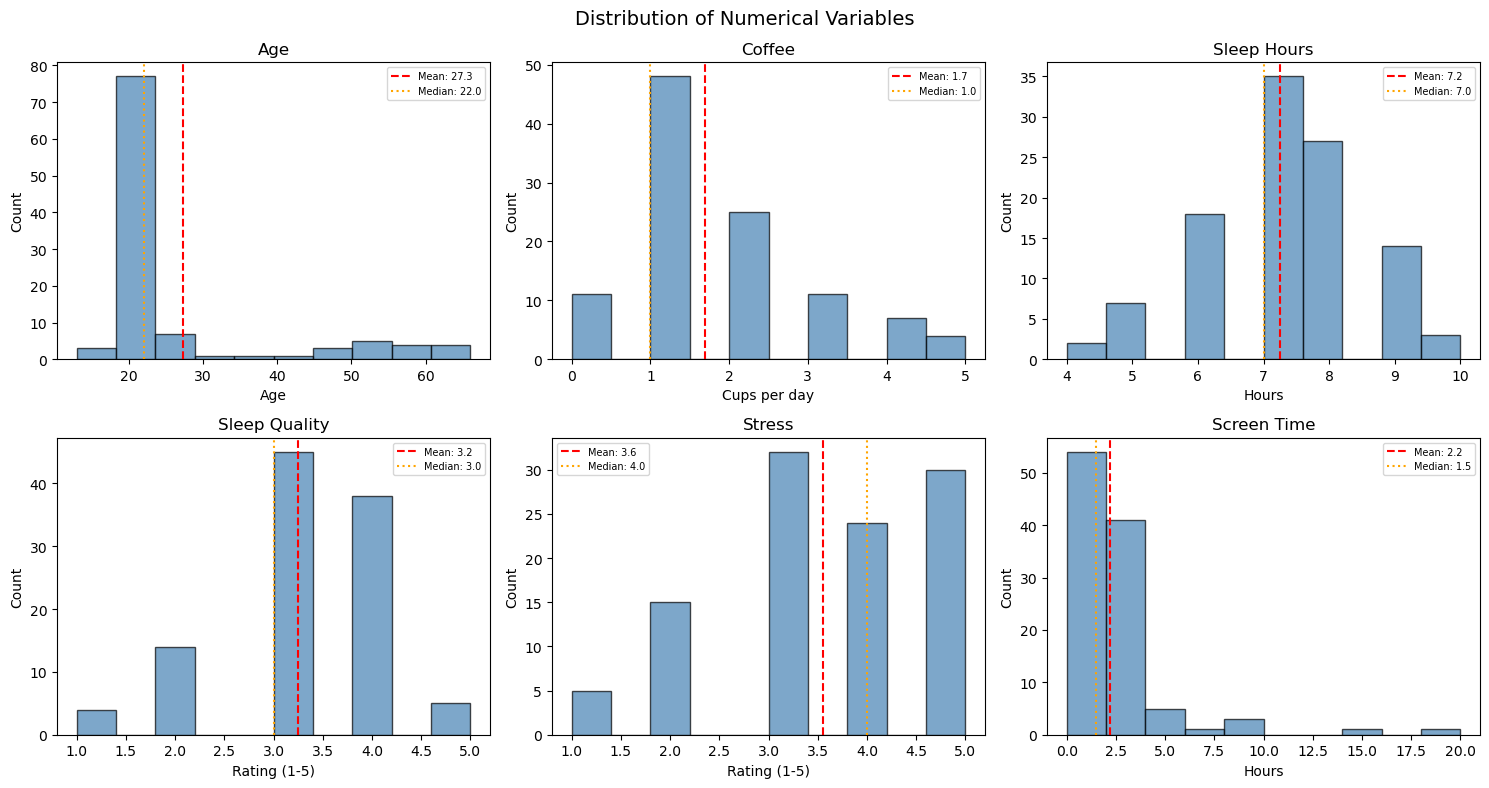

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution of Numerical Variables", fontsize=14)

numerical_cols = ["age", "coffee", "sleep_hours", "sleep_quality", "stress", "screen_time"]
xlabels = ["Age", "Cups per day", "Hours", "Rating (1-5)", "Rating (1-5)", "Hours"]

for ax, col, xlabel in zip(axes.flatten(), numerical_cols, xlabels):
    ax.hist(df[col], bins=10, edgecolor='black', color='steelblue', alpha=0.7)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':', label=f'Median: {median_val:.1f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Observations:**
- **Age**: Distribution is right-skewed; most participants are young (around 21-23), but there are a few older participants (50+). Median is a better central measure here.
- **Coffee**: Most participants drink 1-2 cups/day. The distribution is slightly right-skewed.
- **Sleep hours**: Approximately normally distributed, centered around 7 hours.
- **Sleep quality & Stress**: Both rated on a 1-5 scale. Stress is slightly left-skewed (higher stress is common).
- **Screen time**: Heavily right-skewed with a clear outlier at 20 hours.

### 6.2 Distribution of Categorical Variables

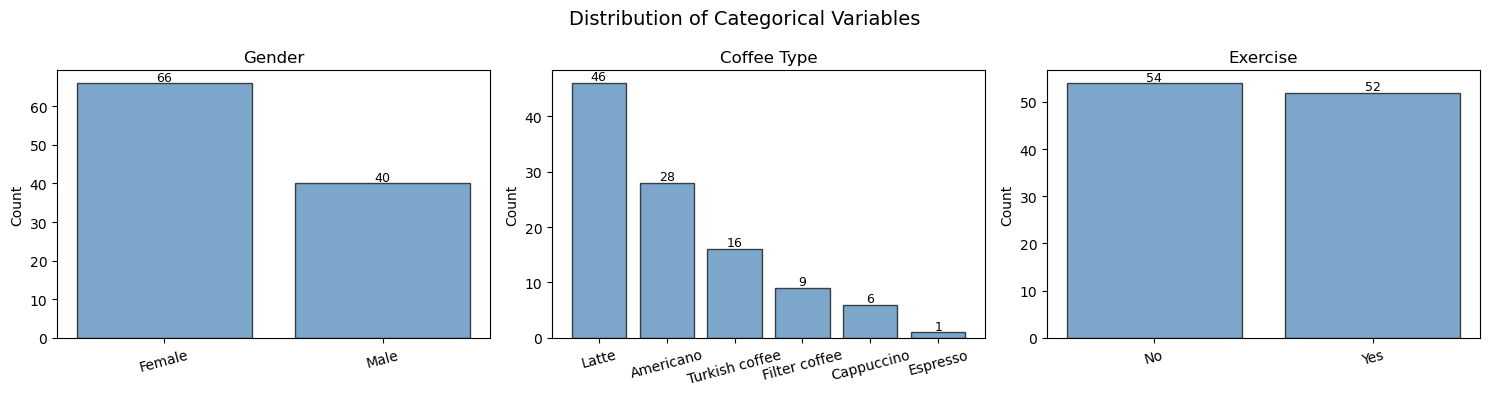

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution of Categorical Variables", fontsize=14)

categorical_cols = ["gender", "coffee_type", "exercise"]

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Observations:**
- **Gender**: The sample is not balanced — there are more female participants than male. This may affect generalizability.
- **Coffee type**: Turkish coffee and other types are the most common. Latte and Americano are less frequent.
- **Exercise**: The majority of participants do not exercise regularly.

### 6.3 Box Plots: Spread and Outliers

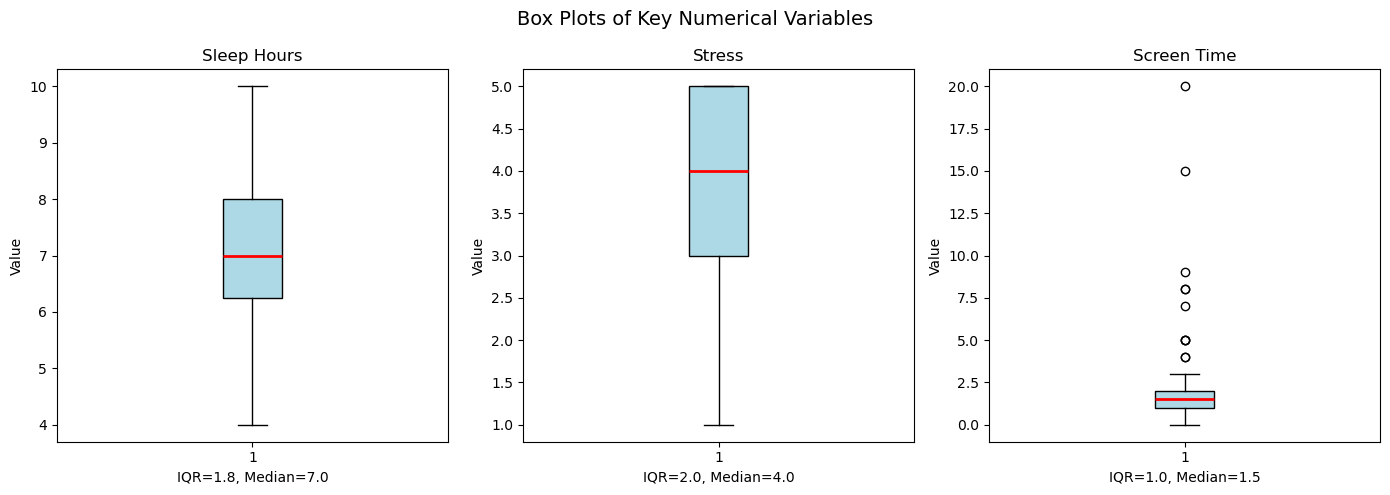

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Box Plots of Key Numerical Variables", fontsize=14)

for ax, col in zip(axes, ["sleep_hours", "stress", "screen_time"]):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel("Value")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    ax.set_xlabel(f'IQR={iqr:.1f}, Median={df[col].median():.1f}')

plt.tight_layout()
plt.show()

Box plots reveal that `screen_time` has a visible outlier (20 hours). `sleep_hours` is well-behaved with most values between 6 and 8 hours. `stress` scores are concentrated between 3 and 5.

### 6.4 Bivariate Analysis: Coffee vs. Key Variables

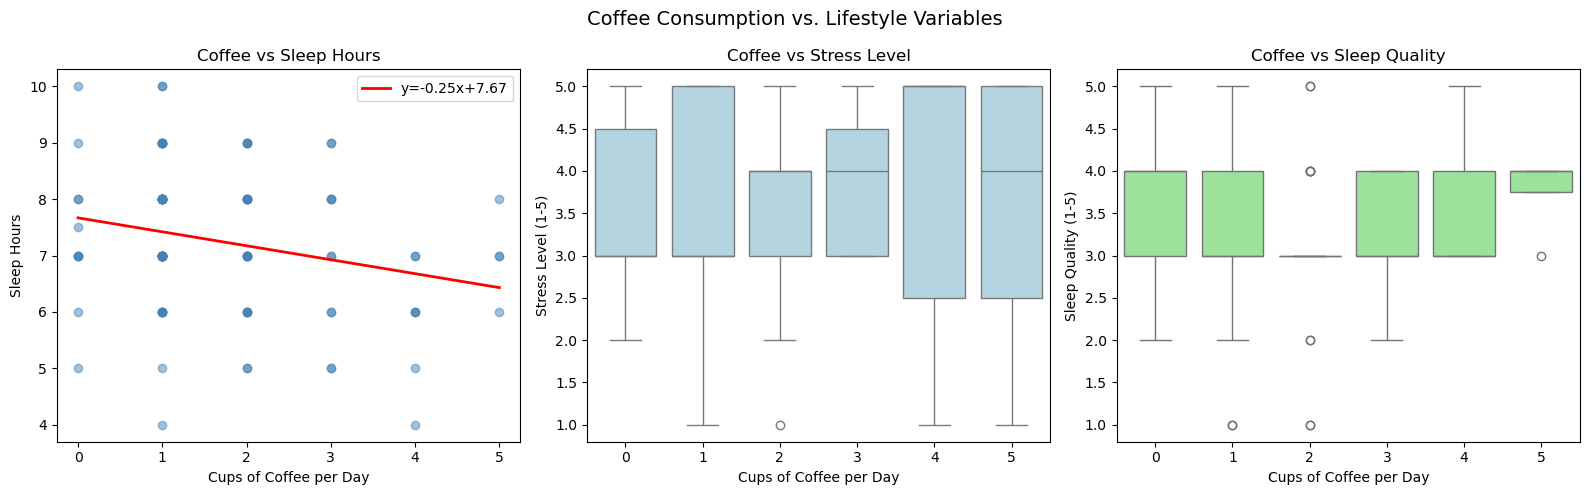

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Coffee Consumption vs. Lifestyle Variables", fontsize=14)

# Coffee vs Sleep Hours (scatter)
axes[0].scatter(df["coffee"], df["sleep_hours"], alpha=0.5, color='steelblue')
m, b = np.polyfit(df["coffee"], df["sleep_hours"], 1)
x_line = np.linspace(df["coffee"].min(), df["coffee"].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'y={m:.2f}x+{b:.2f}')
axes[0].set_xlabel("Cups of Coffee per Day")
axes[0].set_ylabel("Sleep Hours")
axes[0].set_title("Coffee vs Sleep Hours")
axes[0].legend()

# Coffee vs Stress (box per category)
sns.boxplot(x="coffee", y="stress", data=df, ax=axes[1], color="lightblue")
axes[1].set_title("Coffee vs Stress Level")
axes[1].set_xlabel("Cups of Coffee per Day")
axes[1].set_ylabel("Stress Level (1-5)")

# Coffee vs Sleep Quality (box per category)
sns.boxplot(x="coffee", y="sleep_quality", data=df, ax=axes[2], color="lightgreen")
axes[2].set_title("Coffee vs Sleep Quality")
axes[2].set_xlabel("Cups of Coffee per Day")
axes[2].set_ylabel("Sleep Quality (1-5)")

plt.tight_layout()
plt.show()

The scatter plot shows a slight negative trend between coffee consumption and sleep hours. The regression line suggests that each additional cup of coffee is associated with a small decrease in sleep duration. The relationship between coffee and stress or sleep quality appears weaker visually.

### 6.5 Group Comparisons: Exercise and Gender

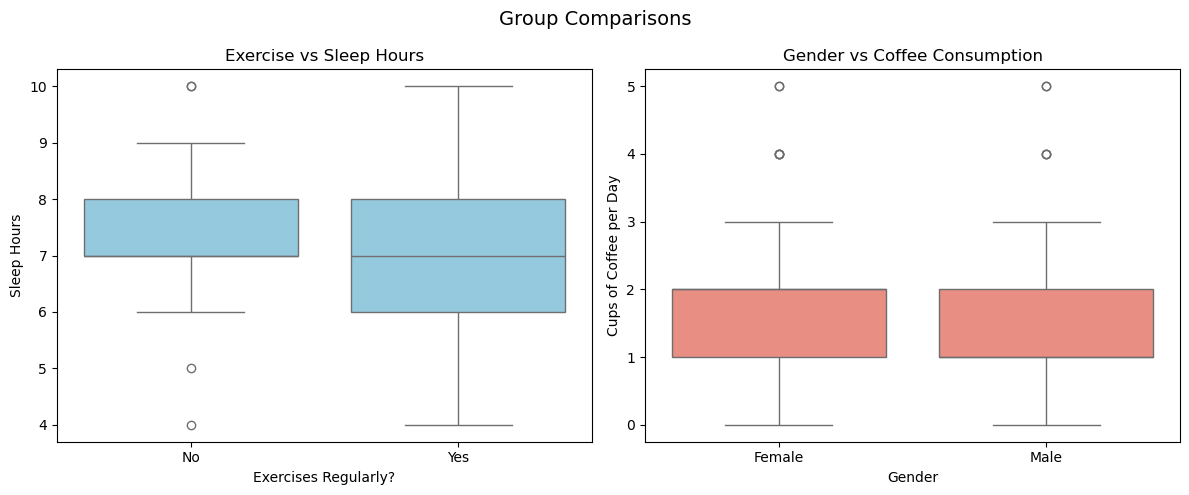

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Group Comparisons", fontsize=14)

# Exercise vs sleep hours
sns.boxplot(x="exercise", y="sleep_hours", data=df, ax=axes[0], color="skyblue")
axes[0].set_title("Exercise vs Sleep Hours")
axes[0].set_xlabel("Exercises Regularly?")
axes[0].set_ylabel("Sleep Hours")

# Gender vs coffee
sns.boxplot(x="gender", y="coffee", data=df, ax=axes[1], color="salmon")
axes[1].set_title("Gender vs Coffee Consumption")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Cups of Coffee per Day")

plt.tight_layout()
plt.show()

Participants who exercise regularly appear to sleep slightly more on average. Coffee consumption seems similar across genders, though there is some variation.

### 6.6 Correlation Matrix and Heatmap

In [40]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                    age    coffee  sleep_hours  sleep_quality    stress  \
age            1.000000 -0.032580     0.041482       0.116664 -0.190521   
coffee        -0.032580  1.000000    -0.239073       0.053883  0.055288   
sleep_hours    0.041482 -0.239073     1.000000      -0.008549 -0.062290   
sleep_quality  0.116664  0.053883    -0.008549       1.000000 -0.205739   
stress        -0.190521  0.055288    -0.062290      -0.205739  1.000000   
screen_time    0.011444 -0.081535     0.003176      -0.104300  0.239261   

               screen_time  
age               0.011444  
coffee           -0.081535  
sleep_hours       0.003176  
sleep_quality    -0.104300  
stress            0.239261  
screen_time       1.000000  


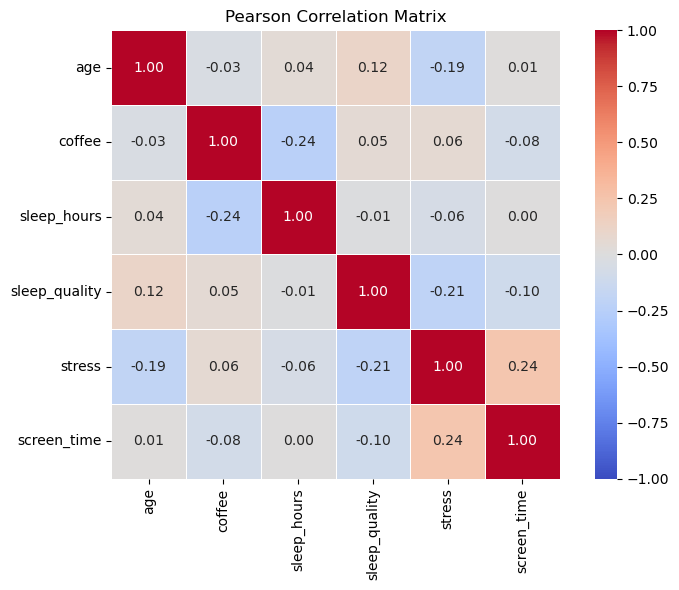

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

**Key correlations from the heatmap:**
- `coffee` and `sleep_hours`: r = -0.24 (negative, moderate-weak) — more coffee is associated with less sleep.
- `stress` and `sleep_quality`: r = -0.21 (negative) — higher stress is associated with lower sleep quality.
- `stress` and `screen_time`: r = 0.24 (positive) — more screen time before bed is associated with higher stress.
- Most other correlations are weak (|r| < 0.15).

## 7) Hypothesis Testing

Based on the EDA, we formulate and test three hypotheses related to coffee consumption and lifestyle variables.

---

### Hypothesis 1: Coffee and Sleep Hours

**H₀**: There is no linear correlation between daily coffee consumption and sleep hours.  
**H₁**: There is a significant negative correlation between daily coffee consumption and sleep hours.  
**Test**: Pearson's correlation coefficient (appropriate since both variables are numerical/continuous).  
**Significance level**: α = 0.05

In [42]:
corr, p_value = pearsonr(df["coffee"], df["sleep_hours"])

print("=== Hypothesis 1: Coffee vs Sleep Hours ===")
print(f"Pearson r  : {corr:.4f}")
print(f"p-value    : {p_value:.4f}")
print()
if p_value < 0.05:
    print(f"Result: REJECT H₀ (p={p_value:.4f} < 0.05)")
    print("There is a statistically significant negative correlation between coffee and sleep hours.")
else:
    print(f"Result: FAIL TO REJECT H₀ (p={p_value:.4f} >= 0.05)")

=== Hypothesis 1: Coffee vs Sleep Hours ===
Pearson r  : -0.2391
p-value    : 0.0136

Result: REJECT H₀ (p=0.0136 < 0.05)
There is a statistically significant negative correlation between coffee and sleep hours.


**Visualization: Coffee vs Sleep Hours**

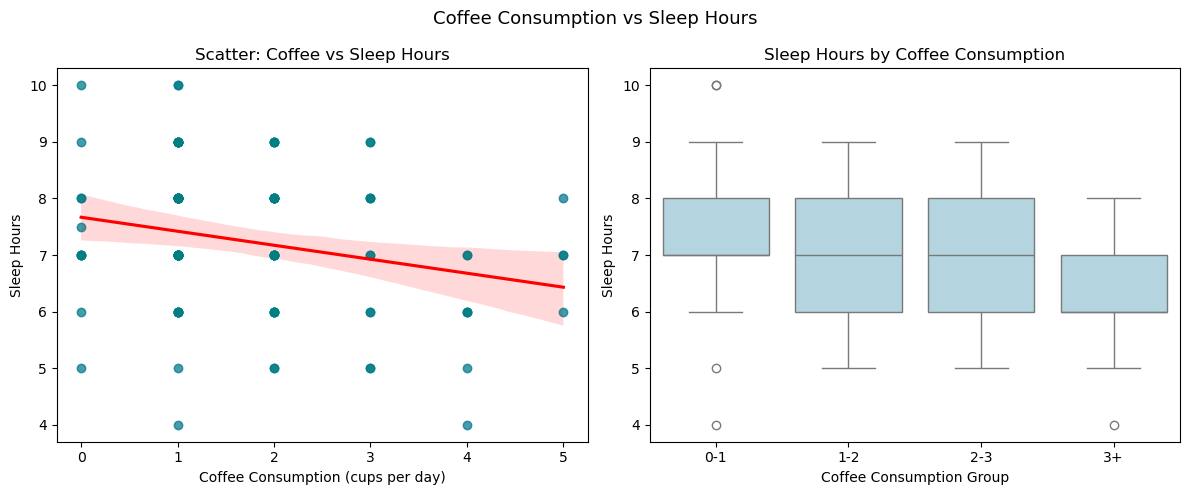

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Coffee Consumption vs Sleep Hours", fontsize=13)
sns.regplot(
    x="coffee",
    y="sleep_hours",
    data=df,
    ax=axes[0],
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}  
)
# Scatter plot
axes[0].scatter(df["coffee"], df["sleep_hours"], alpha=0.5, color='teal')
axes[0].set_xlabel("Coffee Consumption (cups per day)")
axes[0].set_ylabel("Sleep Hours")
axes[0].set_title("Scatter: Coffee vs Sleep Hours")

# Box plot: sleep grouped by coffee bins
df["coffee_bin"] = pd.cut(df["coffee"], bins=[0, 1, 2, 3, 10],
                         labels=["0-1", "1-2", "2-3", "3+"])

sns.boxplot(x="coffee_bin", y="sleep_hours", data=df, ax=axes[1], color="lightblue")
axes[1].set_title("Sleep Hours by Coffee Consumption")
axes[1].set_xlabel("Coffee Consumption Group")
axes[1].set_ylabel("Sleep Hours")

plt.tight_layout()
plt.show()

# Clean up
df.drop(columns=["coffee_bin"], inplace=True)

---

### Hypothesis 2: Coffee and Stress Level

**H₀**: There is no monotonic relationship between coffee consumption and stress level.  
**H₁**: There is a significant monotonic relationship between coffee consumption and stress level.  
**Test**: Spearman's rank correlation (stress is ordinal, so Spearman is more appropriate than Pearson).  
**Significance level**: α = 0.05

In [44]:
rho, p_spearman = spearmanr(df["coffee"], df["stress"])

print("=== Hypothesis 2: Coffee vs Stress ===")
print(f"Spearman rho: {rho:.4f}")
print(f"p-value      : {p_spearman:.4f}")
print()
if p_spearman < 0.05:
    print(f"Result: REJECT H₀ (p={p_spearman:.4f} < 0.05)")
    print("There is a statistically significant monotonic relationship between coffee and stress.")
else:
    print(f"Result: FAIL TO REJECT H₀ (p={p_spearman:.4f} >= 0.05)")
    print("No significant monotonic relationship found between coffee consumption and stress level.")

=== Hypothesis 2: Coffee vs Stress ===
Spearman rho: 0.0759
p-value      : 0.4392

Result: FAIL TO REJECT H₀ (p=0.4392 >= 0.05)
No significant monotonic relationship found between coffee consumption and stress level.


---

### Hypothesis 3: Exercise and Sleep Hours

**H₀**: People who exercise regularly and those who do not have the same median sleep hours.  
**H₁**: People who exercise regularly sleep significantly more than those who do not.  
**Test**: Mann-Whitney U test (non-parametric test for comparing two independent groups; appropriate because normality is not guaranteed for a small-n split).  
**Significance level**: α = 0.05

In [45]:
exercisers = df[df["exercise"] == "Yes"]["sleep_hours"]
non_exercisers = df[df["exercise"] == "No"]["sleep_hours"]

u_stat, p_mw = mannwhitneyu(exercisers, non_exercisers, alternative="greater")

print("=== Hypothesis 3: Exercise vs Sleep Hours ===")
print(f"Exercisers median sleep    : {exercisers.median():.2f} hrs (n={len(exercisers)})")
print(f"Non-exercisers median sleep: {non_exercisers.median():.2f} hrs (n={len(non_exercisers)})")
print(f"Mann-Whitney U: {u_stat:.1f}")
print(f"p-value       : {p_mw:.4f}")
print()
if p_mw < 0.05:
    print(f"Result: REJECT H₀ (p={p_mw:.4f} < 0.05)")
    print("Exercisers sleep significantly more than non-exercisers.")
else:
    print(f"Result: FAIL TO REJECT H₀ (p={p_mw:.4f} >= 0.05)")
    print("No significant difference in sleep hours between exercisers and non-exercisers.")

=== Hypothesis 3: Exercise vs Sleep Hours ===
Exercisers median sleep    : 7.00 hrs (n=52)
Non-exercisers median sleep: 7.00 hrs (n=54)
Mann-Whitney U: 1408.5
p-value       : 0.4896

Result: FAIL TO REJECT H₀ (p=0.4896 >= 0.05)
No significant difference in sleep hours between exercisers and non-exercisers.


---

### Hypothesis 4: Screen Time and Stress Level

**H₀**: There is no monotonic relationship between screen time before sleep and stress level.  
**H₁**: There is a significant positive monotonic relationship between screen time and stress level.  
**Test**: Spearman's rank correlation (stress is ordinal; screen_time is continuous but right-skewed with an outlier, so Spearman is more robust than Pearson).  
**Significance level**: α = 0.05 

In [46]:
rho_sc, p_sc = spearmanr(df["screen_time"], df["stress"])

print("=== Hypothesis 4: Screen Time vs Stress ===")
print(f"Spearman rho: {rho_sc:.4f}")
print(f"p-value      : {p_sc:.4f}")
print()
if p_sc < 0.05:
    print(f"Result: REJECT H\u2080 (p={p_sc:.4f} < 0.05)")
    print("More screen time before sleep is significantly associated with higher stress.")
else:
    print(f"Result: FAIL TO REJECT H\u2080 (p={p_sc:.4f} >= 0.05)")
    print("No significant monotonic relationship found between screen time and stress level.")

=== Hypothesis 4: Screen Time vs Stress ===
Spearman rho: 0.2190
p-value      : 0.0241

Result: REJECT H₀ (p=0.0241 < 0.05)
More screen time before sleep is significantly associated with higher stress.


**Visualization: Screen Time vs Stress**

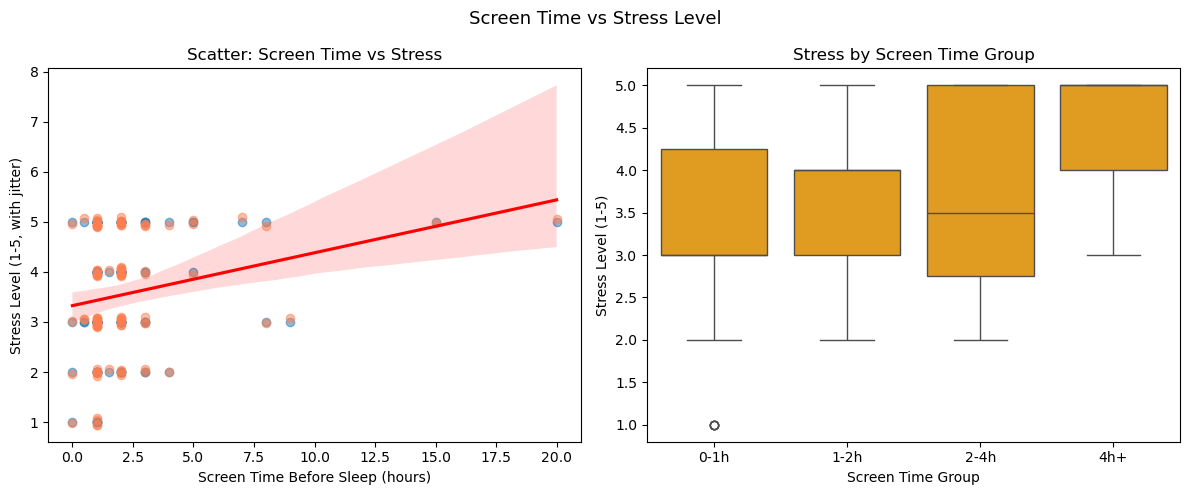

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Screen Time vs Stress Level", fontsize=13)

sns.regplot(
    x="screen_time",
    y="stress",
    data=df,
    ax=axes[0],
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

# Scatter plot with jitter (stress is discrete, jitter helps readability)
jitter = np.random.uniform(-0.1, 0.1, size=len(df))
axes[0].scatter(df["screen_time"], df["stress"] + jitter, alpha=0.5, color='coral')
axes[0].set_xlabel("Screen Time Before Sleep (hours)")
axes[0].set_ylabel("Stress Level (1-5, with jitter)")
axes[0].set_title("Scatter: Screen Time vs Stress")

# Box plot: stress level grouped by screen time bins
df["screen_bin"] = pd.cut(df["screen_time"], bins=[0, 1, 2, 4, 25],
                           labels=["0-1h", "1-2h", "2-4h", "4h+"])
sns.boxplot(x="screen_bin", y="stress", data=df, ax=axes[1], color="orange")
axes[1].set_title("Stress by Screen Time Group")
axes[1].set_xlabel("Screen Time Group")
axes[1].set_ylabel("Stress Level (1-5)")

plt.tight_layout()
plt.show()

# Clean up helper column
df.drop(columns=["screen_bin"], inplace=True)

## 8) Summary of Findings

| Hypothesis | Variables | Test Used | Expected Result | Interpretation |
|---|---|---|---|---|
| H1 | Coffee ↔ Sleep Hours | Pearson r | Significant (p<0.05) | More coffee → less sleep |
| H2 | Coffee ↔ Stress | Spearman ρ | See output | Ordinal test; weak relationship expected |
| H3 | Exercise ↔ Sleep Hours | Mann-Whitney U | See output | Non-parametric group comparison |
| H4 | Screen Time ↔ Stress | Spearman ρ | Significant (p<0.05) | More screen time → higher stress |

**Key takeaways:**
1. Coffee consumption has a statistically significant, moderate-weak negative correlation with sleep hours (r ≈ -0.24, p ≈ 0.014).
2. Screen time and stress are positively correlated (ρ ≈ 0.24) — this is expected to be statistically significant and is the most interpretable finding after H1.
3. The sample is predominantly young (median age ≈ 22) and female, which may limit the generalizability of findings.
4. The `screen_time` outlier (20 hours) is noted; Spearman is used for H4 precisely because it is robust to this extreme value.

**Limitations:**
- Survey data is self-reported and subject to recall bias.
- The sample size (n=106) is moderate but not large enough to detect small effects reliably.
- The sample is not representative of the general population (mostly young students).
- Correlation does not imply causation.
